Saving snsdata.csv to snsdata (1).csv
Data Loaded Successfully

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 40 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gradyear      30000 non-null  int64  
 1   gender        27276 non-null  object 
 2   age           24914 non-null  float64
 3   friends       30000 non-null  int64  
 4   basketball    30000 non-null  int64  
 5   football      30000 non-null  int64  
 6   soccer        30000 non-null  int64  
 7   softball      30000 non-null  int64  
 8   volleyball    30000 non-null  int64  
 9   swimming      30000 non-null  int64  
 10  cheerleading  30000 non-null  int64  
 11  baseball      30000 non-null  int64  
 12  tennis        30000 non-null  int64  
 13  sports        30000 non-null  int64  
 14  cute          30000 non-null  int64  
 15  sex           30000 non-null  int64  
 16  sexy          30000 non-null  int6

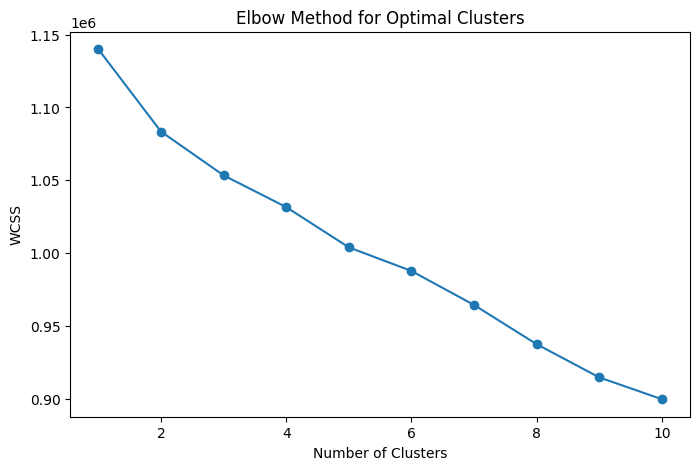

 Clustering Completed


In [1]:
# ==========================================
# Nikita Porwal | Data Science Portfolio
# Project: Customer Segmentation using Clustering (snsdata)
# ==========================================

# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# LOAD DATA
# ===============================
# Upload snsdata.csv in Colab
from google.colab import files
uploaded = files.upload()

data = pd.read_csv("snsdata.csv")
print("Data Loaded Successfully")
data.head()

# ===============================
# UNDERSTANDING DATA
# ===============================
print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

# ===============================
# DATA CLEANING
# ===============================
# Fill missing age with median
data['age'] = data['age'].fillna(data['age'].median())

# Fill remaining missing values with 0
data.fillna(0, inplace=True)

print("Missing values handled")

# ===============================
# FEATURE SELECTION
# ===============================
# Remove non-numeric / ID columns
if "gradyear" in data.columns:
    data_num = data.drop(columns=["gradyear"])
else:
    data_num = data.copy()

# Keep only numeric features
data_num = data_num.select_dtypes(include=[np.number])

# ===============================
# FEATURE SCALING
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_num)

print("Data Scaled")

# ===============================
# FIND OPTIMAL CLUSTERS (ELBOW METHOD)
# ===============================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ===============================
# FINAL MODEL (KMEANS)
# ===============================
optimal_clusters = 4  # change based on elbow graph

kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

print(" Clustering Completed")

# ===============================
# 📉 VISUALISATION (PCA)
# ===============================
pca = PCA(n_components=2)